In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("all-state-changes.csv")
df

,state,timestamp,leading_candidate_name,trailing_candidate_name,leading_candidate_votes,trailing_candidate_votes,vote_differential,votes_remaining,new_votes,new_votes_relevant,new_votes_formatted,leading_candidate_partition,trailing_candidate_partition,precincts_reporting,precincts_total,hurdle,hurdle_change,hurdle_mov_avg,counties_partition,total_votes_count
0,Alaska (EV: 3),2020-12-02 19:04:28.768000,Trump,Biden,189951,153778,36173,31816,0,0,0,0.000000,0.000000,441,441,1.094604,0.000000,0.494467,{},359530
1,Alaska (EV: 3),2020-12-02 17:18:21.996000,Trump,Biden,189951,153778,36173,31816,0,0,0,0.000000,0.000000,441,441,1.094604,0.000000,0.494467,{},359530
2,Alaska (EV: 3),2020-12-02 16:33:22.842000,Trump,Biden,189951,153778,36173,31816,0,0,0,0.000000,0.000000,441,441,1.094604,0.000000,0.494467,{},359530
3,Alaska (EV: 3),2020-12-02 15:22:19.152000,Trump,Biden,189951,153778,36173,31816,2304,587,587,0.226576,0.773424,441,441,1.094604,0.035231,0.494467,"{'ED 10': 51, 'ED 37': 102, 'ED 39': 119, 'ED ...",359530
4,Alaska (EV: 3),2020-12-01 18:45:19.099000,Trump,Biden,189818,153324,36494,34120,58,0,0,0.000000,0.000000,424,441,1.059373,0.000949,0.488333,{'ED 6': 58},357226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3401,Wyoming (EV: 3),2020-11-11 22:19:53.904000,Trump,Biden,193559,73491,120068,0,0,0,0,0.000000,0.000000,483,483,0.000000,0.000000,0.154079,{},276765
3402,Wyoming (EV: 3),2020-11-11 21:14:13.744000,Trump,Biden,193559,73491,120068,0,84,0,0,0.000000,0.000000,444,483,0.000000,-741.190169,0.154079,"{'Laramie': 1, 'Sweetwater': 83}",276765
3403,Wyoming (EV: 3),2020-11-11 20:39:54.585000,Trump,Biden,193559,73491,120068,84,153,151,151,0.695364,0.304636,444,483,741.190169,478.296072,0.154079,"{'Albany': 5, 'Campbell': 2, 'Carbon': 2, 'Con...",276681
3404,Wyoming (EV: 3),2020-11-06 02:50:08.240000,Trump,Biden,193454,73445,120009,237,185,180,180,0.972222,0.027778,444,483,262.894097,115.239337,0.027778,{'Niobrara': 185},276528


In [5]:
df['rep_votes'] = np.where(
    df['leading_candidate_name'] == 'Trump', 
    df['leading_candidate_votes'], 
    df['trailing_candidate_votes']
)

df['dem_votes'] = np.where(
    df['leading_candidate_name'] == 'Biden', 
    df['leading_candidate_votes'], 
    df['trailing_candidate_votes']
)

df = df.drop(columns=[
    'leading_candidate_name', 
    'trailing_candidate_name', 
    'leading_candidate_votes', 
    'trailing_candidate_votes'
])

df

,state,timestamp,vote_differential,votes_remaining,new_votes,new_votes_relevant,new_votes_formatted,leading_candidate_partition,trailing_candidate_partition,precincts_reporting,precincts_total,hurdle,hurdle_change,hurdle_mov_avg,counties_partition,total_votes_count,rep_votes,dem_votes
0,Alaska (EV: 3),2020-12-02 19:04:28.768000,36173,31816,0,0,0,0.000000,0.000000,441,441,1.094604,0.000000,0.494467,{},359530,189951,153778
1,Alaska (EV: 3),2020-12-02 17:18:21.996000,36173,31816,0,0,0,0.000000,0.000000,441,441,1.094604,0.000000,0.494467,{},359530,189951,153778
2,Alaska (EV: 3),2020-12-02 16:33:22.842000,36173,31816,0,0,0,0.000000,0.000000,441,441,1.094604,0.000000,0.494467,{},359530,189951,153778
3,Alaska (EV: 3),2020-12-02 15:22:19.152000,36173,31816,2304,587,587,0.226576,0.773424,441,441,1.094604,0.035231,0.494467,"{'ED 10': 51, 'ED 37': 102, 'ED 39': 119, 'ED ...",359530,189951,153778
4,Alaska (EV: 3),2020-12-01 18:45:19.099000,36494,34120,58,0,0,0.000000,0.000000,424,441,1.059373,0.000949,0.488333,{'ED 6': 58},357226,189818,153324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3401,Wyoming (EV: 3),2020-11-11 22:19:53.904000,120068,0,0,0,0,0.000000,0.000000,483,483,0.000000,0.000000,0.154079,{},276765,193559,73491
3402,Wyoming (EV: 3),2020-11-11 21:14:13.744000,120068,0,84,0,0,0.000000,0.000000,444,483,0.000000,-741.190169,0.154079,"{'Laramie': 1, 'Sweetwater': 83}",276765,193559,73491
3403,Wyoming (EV: 3),2020-11-11 20:39:54.585000,120068,84,153,151,151,0.695364,0.304636,444,483,741.190169,478.296072,0.154079,"{'Albany': 5, 'Campbell': 2, 'Carbon': 2, 'Con...",276681,193559,73491
3404,Wyoming (EV: 3),2020-11-06 02:50:08.240000,120009,237,185,180,180,0.972222,0.027778,444,483,262.894097,115.239337,0.027778,{'Niobrara': 185},276528,193454,73445


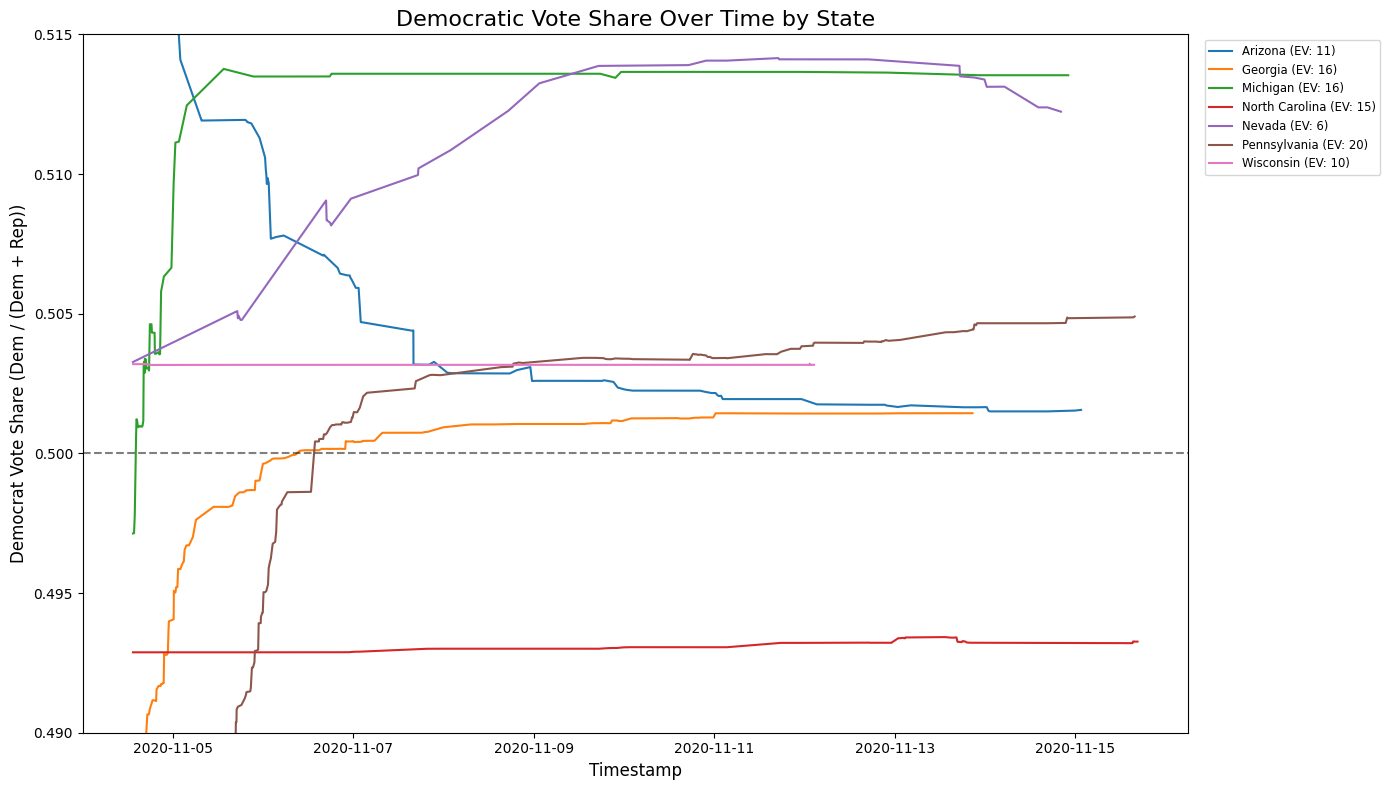

In [ ]:
# 1. Ensure the timestamp column is a datetime object so it plots correctly
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. Calculate the Democratic vote share
# (Make sure you've already created dem_votes and rep_votes as shown previously)
df['dem_share'] = df['dem_votes'] / (df['dem_votes'] + df['rep_votes'])

# 3. Create the plot
plt.figure(figsize=(14, 8))


# Optional: Filter for just the swing states
swing_states = ['Pennsylvania (EV: 20)', 'Georgia (EV: 16)', 'Michigan (EV: 16)', 
                'Wisconsin (EV: 10)', 'Arizona (EV: 11)', 'Nevada (EV: 6)', 'North Carolina (EV: 15)']

swing_df = df[df['state'].isin(swing_states)]
swing_df_filtered = swing_df[swing_df['timestamp'] < '2020-11-16'].copy()


# Then plug `swing_df` into sns.lineplot instead of `df`
# sns.lineplot automatically groups by 'state' when you use the 'hue' parameter
sns.lineplot(data=swing_df_filtered, x='timestamp', y='dem_share', hue='state', linewidth=1.5)

# 4. Formatting the chart
plt.title('Democratic Vote Share Over Time by State', fontsize=16)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Democrat Vote Share (Dem / (Dem + Rep))', fontsize=12)


plt.ylim(0.49, 0.515)
# Add a horizontal line at 0.5 (50%) to easily see who is winning the two-party vote
plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.5)

# Move the legend outside the plot area so it doesn't cover up the lines (since there are ~50 states)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

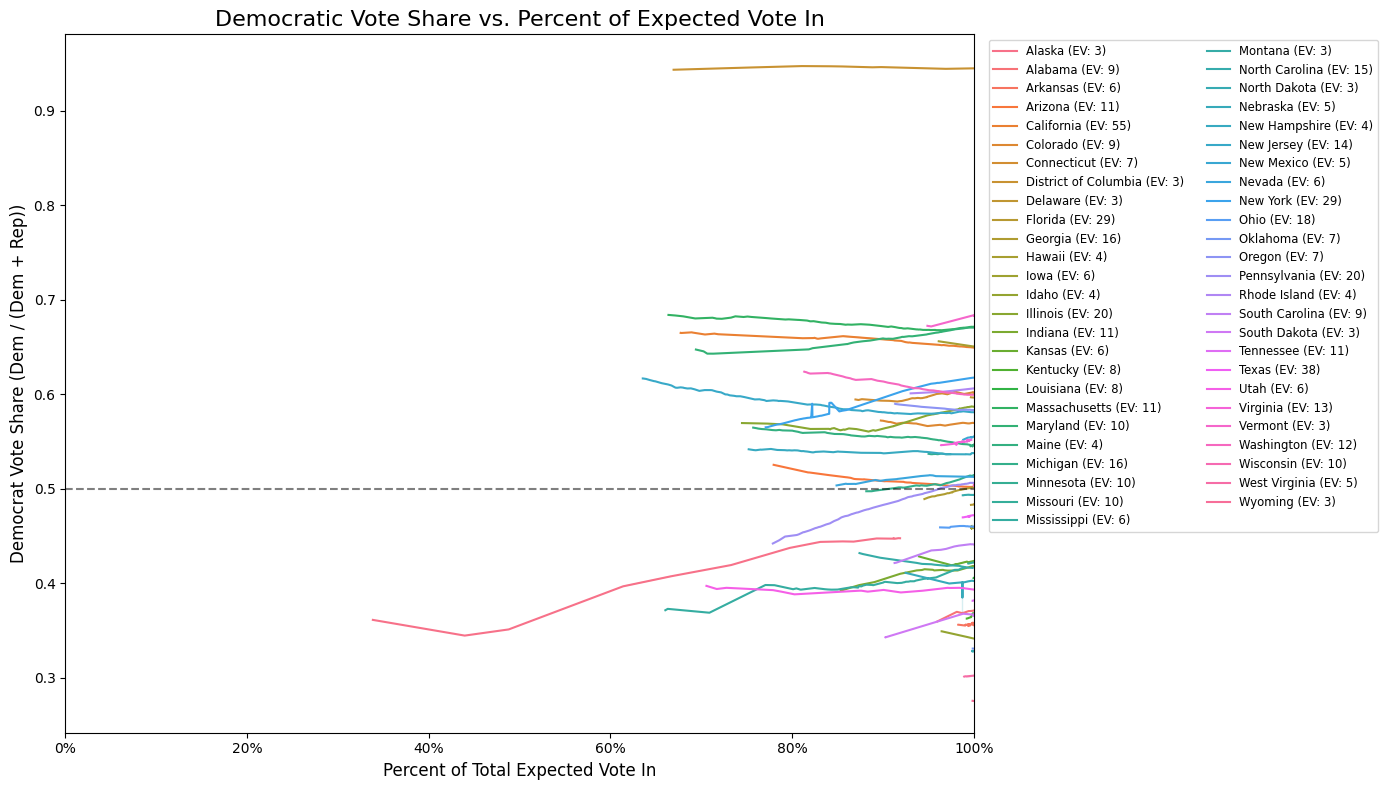

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# 1. Ensure the timestamp column is a datetime object
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. Filter the data to include only rows up to November 15, 2020

# 3. Calculate the Democratic vote share
df['dem_share'] = df['dem_votes'] / (df['dem_votes'] + df['rep_votes'])

# 4. Calculate the percent of expected vote in
# We find the percentage by dividing current votes by (current votes + remaining votes)
df['total_expected_votes'] = df['total_votes_count'] + df['votes_remaining']
df['percent_vote_in'] = df['total_votes_count'] / df['total_expected_votes']

swing_states = ['Pennsylvania (EV: 20)', 'Georgia (EV: 16)', 'Michigan (EV: 16)', 
                'Wisconsin (EV: 10)', 'Arizona (EV: 11)', 'Nevada (EV: 6)', 'North Carolina (EV: 15)']

swing_df = df[df['state'].isin(swing_states)]

# 5. Create the plot
plt.figure(figsize=(14, 8))

# Update x to 'percent_vote_in'
sns.lineplot(data=df, x='percent_vote_in', y='dem_share', hue='state', linewidth=1.5)

# 6. Formatting the chart
plt.title('Democratic Vote Share vs. Percent of Expected Vote In', fontsize=16)
plt.xlabel('Percent of Total Expected Vote In', fontsize=12)
plt.ylabel('Democrat Vote Share (Dem / (Dem + Rep))', fontsize=12)

# Set the y-axis limits to zoom in on the 0.48 to 0.52 range

# Set the x-axis limits from 0 to 1 (0% to 100%)
plt.xlim(0, 1.0)

# Format the x-axis to show percentages (e.g., 90% instead of 0.9)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))

# Add a horizontal line at 0.5 (50%)
plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.5)

# Move the legend outside the plot area
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', ncol=2, fontsize='small')

plt.tight_layout()
plt.show()